CSV 저장 완료: RXRX_stock_with_indicators.csv

=== 최근 5개 데이터 ===
            Open   High    Low  Close    Volume   MA_5   MA_20     MA_60  \
Date                                                                       
2026-03-11  3.44  3.560  3.340   3.45  14397900  3.480  3.5635  4.109000   
2026-03-12  3.40  3.400  3.220   3.29  18345400  3.430  3.5425  4.091667   
2026-03-13  3.35  3.520  3.345   3.42  14409900  3.422  3.5345  4.078667   
2026-03-16  3.45  3.505  3.370   3.39  10458300  3.398  3.5295  4.065167   
2026-03-17  3.39  3.480  3.360   3.42  10278571  3.394  3.5275  4.044167   

              MA_120    MA_240  BB_MID  BB_UPPER  BB_LOWER     RSI_14  
Date                                                                   
2026-03-11  4.594417  4.855792  3.5635  3.796763  3.330237  40.061497  
2026-03-12  4.580750  4.844625  3.5425  3.795055  3.289945  35.825214  
2026-03-13  4.568333  4.834667  3.5345  3.792139  3.276861  41.260201  
2026-03-16  4.555083  4.826750  3.5295  3.7945

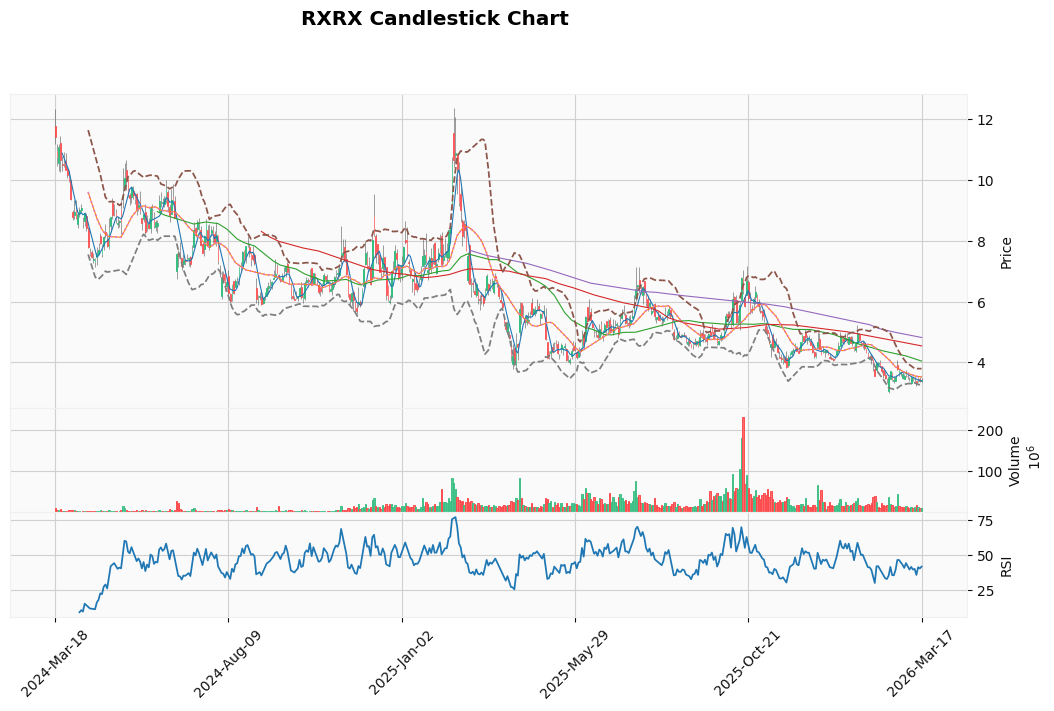

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import mplfinance as mpf


def calculate_rsi(close: pd.Series, period: int = 14) -> pd.Series:
    """
    Wilder 방식에 가까운 RSI 계산
    """
    delta = close.diff()

    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)

    avg_gain = gain.ewm(alpha=1 / period, min_periods=period, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1 / period, min_periods=period, adjust=False).mean()

    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi


def add_indicators(df: pd.DataFrame) -> pd.DataFrame:
    """
    이동평균선, 볼린저밴드, RSI 계산
    """
    result = df.copy()

    # 이동평균선
    ma_periods = [5, 20, 60, 120, 240]
    for period in ma_periods:
        result[f"MA_{period}"] = result["Close"].rolling(window=period).mean()

    # 볼린저밴드 (20일, 2표준편차)
    bb_period = 20
    bb_std = 2
    result["BB_MID"] = result["Close"].rolling(window=bb_period).mean()
    rolling_std = result["Close"].rolling(window=bb_period).std()
    result["BB_UPPER"] = result["BB_MID"] + (rolling_std * bb_std)
    result["BB_LOWER"] = result["BB_MID"] - (rolling_std * bb_std)

    # RSI
    result["RSI_14"] = calculate_rsi(result["Close"], period=14)

    return result


def get_stock_data(ticker: str, period: str = "2y", interval: str = "1d") -> pd.DataFrame:
    """
    야후 파이낸스에서 주가 데이터 다운로드
    """
    df = yf.download(
        ticker,
        period=period,
        interval=interval,
        auto_adjust=False,
        progress=False
    )

    if df.empty:
        raise ValueError(f"{ticker} 데이터가 비어 있습니다. 티커를 확인하세요.")

    # yfinance 버전에 따라 MultiIndex 컬럼이 나올 수 있음
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = [col[0] for col in df.columns]

    required_cols = ["Open", "High", "Low", "Close", "Volume"]
    missing = [col for col in required_cols if col not in df.columns]
    if missing:
        raise ValueError(f"필수 컬럼이 없습니다: {missing}")

    df = df[required_cols].copy()
    df.dropna(inplace=True)

    # 인덱스 이름 정리
    df.index.name = "Date"

    return df


def save_to_csv(df: pd.DataFrame, ticker: str, filename: str = None) -> str:
    """
    CSV 파일로 저장
    """
    if filename is None:
        filename = f"{ticker}_stock_with_indicators.csv"

    df_to_save = df.copy()
    df_to_save.to_csv(filename, encoding="utf-8-sig")

    return filename


def plot_candlestick(df: pd.DataFrame, ticker: str, save_chart: bool = False):
    """
    mplfinance로 캔들차트 + 이동평균 + 볼린저밴드 + 거래량 + RSI 표시
    """
    plot_df = df.copy()

    # mplfinance addplot 구성
    add_plots = [
        mpf.make_addplot(plot_df["BB_UPPER"], linestyle="dashed"),
        mpf.make_addplot(plot_df["BB_MID"], linestyle="dotted"),
        mpf.make_addplot(plot_df["BB_LOWER"], linestyle="dashed"),

        mpf.make_addplot(plot_df["RSI_14"], panel=2, ylabel="RSI"),
    ]

    chart_kwargs = dict(
        type="candle",
        mav=(5, 20, 60, 120, 240),
        volume=True,
        addplot=add_plots,
        title=f"{ticker} Candlestick Chart",
        ylabel="Price",
        ylabel_lower="Volume",
        panel_ratios=(6, 2, 2),   # 가격 / 거래량 / RSI
        figscale=1.3,
        figratio=(16, 9),
        style="yahoo"
    )

    if save_chart:
        chart_file = f"{ticker}_candlestick_chart.png"
        mpf.plot(plot_df, savefig=chart_file, **chart_kwargs)
        print(f"차트 이미지 저장 완료: {chart_file}")
    else:
        mpf.plot(plot_df, **chart_kwargs)


def main():
    ticker = "RXRX"

    # 240일 이평선 계산을 위해 기간은 넉넉히 확보
    raw_df = get_stock_data(ticker=ticker, period="2y", interval="1d")
    df = add_indicators(raw_df)

    # CSV 저장
    csv_file = save_to_csv(df, ticker)
    print(f"CSV 저장 완료: {csv_file}")

    # 최근 데이터 출력
    print("\n=== 최근 5개 데이터 ===")
    print(df.tail(5))

    print("\n=== 최근 1개 데이터 요약 ===")
    latest = df.iloc[-1]
    print(f"Date       : {df.index[-1].date()}")
    print(f"Open       : {latest['Open']:.2f}")
    print(f"High       : {latest['High']:.2f}")
    print(f"Low        : {latest['Low']:.2f}")
    print(f"Close      : {latest['Close']:.2f}")
    print(f"Volume     : {int(latest['Volume'])}")
    print(f"MA_5       : {latest['MA_5']:.2f}" if pd.notna(latest["MA_5"]) else "MA_5       : NaN")
    print(f"MA_20      : {latest['MA_20']:.2f}" if pd.notna(latest["MA_20"]) else "MA_20      : NaN")
    print(f"MA_60      : {latest['MA_60']:.2f}" if pd.notna(latest["MA_60"]) else "MA_60      : NaN")
    print(f"MA_120     : {latest['MA_120']:.2f}" if pd.notna(latest["MA_120"]) else "MA_120     : NaN")
    print(f"MA_240     : {latest['MA_240']:.2f}" if pd.notna(latest["MA_240"]) else "MA_240     : NaN")
    print(f"BB_UPPER   : {latest['BB_UPPER']:.2f}" if pd.notna(latest["BB_UPPER"]) else "BB_UPPER   : NaN")
    print(f"BB_MID     : {latest['BB_MID']:.2f}" if pd.notna(latest["BB_MID"]) else "BB_MID     : NaN")
    print(f"BB_LOWER   : {latest['BB_LOWER']:.2f}" if pd.notna(latest["BB_LOWER"]) else "BB_LOWER   : NaN")
    print(f"RSI_14     : {latest['RSI_14']:.2f}" if pd.notna(latest["RSI_14"]) else "RSI_14     : NaN")

    # 캔들차트 표시
    plot_candlestick(df, ticker, save_chart=False)


if __name__ == "__main__":
    main()

## Summary

,Metric,Value
0,Latest Date,2026-03-17 00:00:00
1,Close,3.42
2,BB Width,15.19
3,BW Percentile(120d),10.00
4,Squeeze Level,Squeeze
5,RSI_14,41.70
6,Volume Ratio(20),0.60
7,BULL_SCORE,0
8,BEAR_SCORE,4
9,SCORE_DIFF,-4


## Recent Changes

,Period,Past_BW,Current_BW,Change,Change_%
0,1W,14.48,15.19,0.71,4.89
1,2W,21.87,15.19,-6.68,-30.55
2,3W,38.07,15.19,-22.88,-60.11
3,4W,43.18,15.19,-27.99,-64.83


## Recent 20 Days Snapshot

...

최근 이벤트 로그 기준으로 마지막 30개 이벤트를 검토했습니다.
'Squeeze' 는 12회 발생했습니다.
'Squeeze release' 는 6회 발생했습니다.
'Bullish breakout candidate' 는 5회 발생했습니다.
'Bullish breakout confirmed' 는 2회 발생했습니다.
'Failed bullish breakout' 는 2회 발생했습니다.
'Bearish breakdown candidate' 는 2회 발생했습니다.
'Failed bearish breakdown' 는 1회 발생했습니다.
확정된 상승 돌파 이벤트가 존재하므로, 단순 감시 단계를 넘어 실제 추세 전개가 있었는지 추가 확인이 필요합니다.
실패한 돌파 이벤트가 있었다면 최근 구간에 허위 신호가 존재했음을 의미하므로, 후속 거래량과 유지력을 더 중시해야 합니다.
squeeze 또는 release 이벤트가 반복되면, 큰 방향성 움직임 직전의 압축-해제 패턴일 가능성을 고려할 수 있습니다.


## Action Guide

상방 확인 기준: 종가가 BB_UPPER 위에서 마감하고, 거래량 비율이 1.5 이상이며, RSI가 50 이상 유지되는지 확인합니다.
하방 확인 기준: 종가가 BB_LOWER 아래에서 마감하고, 거래량 비율이 1.5 이상이며, RSI가 45 이하로 약화되는지 확인합니다.
진짜 돌파 여부는 당일 신호보다 다음날 follow-through 유지 여부를 더 중요하게 봅니다.
밴드폭이 다시 커지면서 가격이 밴드 바깥 또는 중심선 위아래에서 안착하는지 확인하는 것이 중요합니다.
현재는 중립 또는 편향 단계이므로, 단독 지표보다 가격, 거래량, 밴드폭의 동시 확인이 중요합니다.


## Risk Checklist

거래량이 평균 이하라 신호 신뢰도가 낮을 수 있습니다.


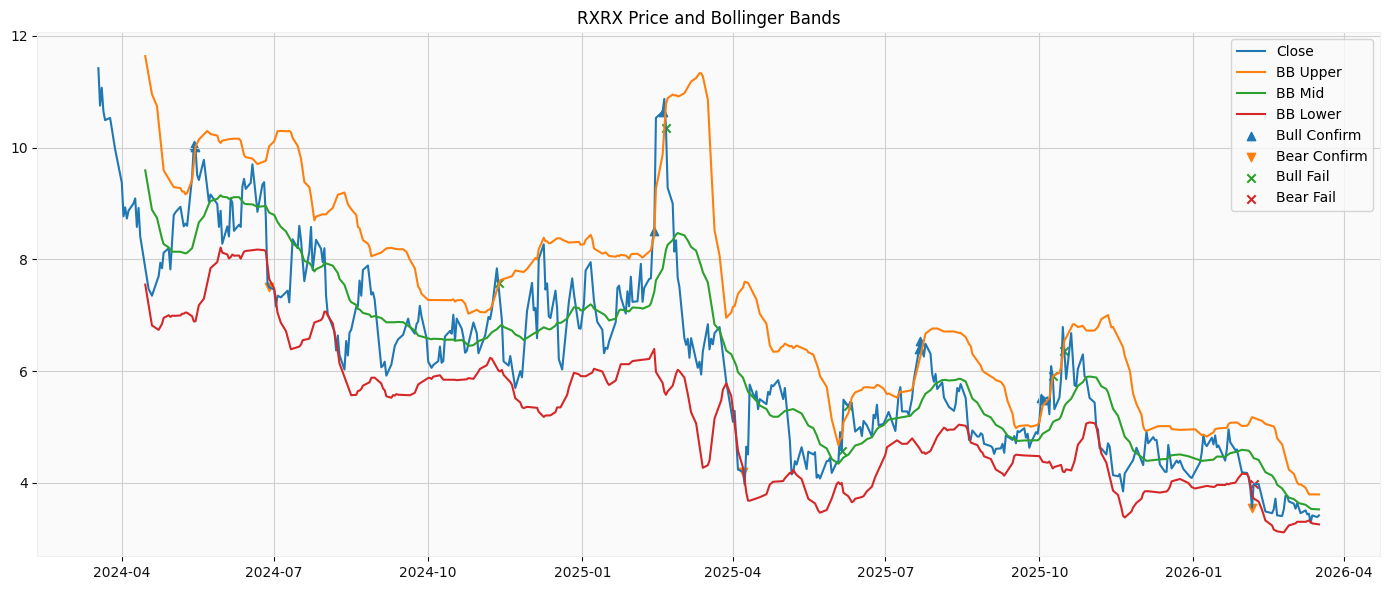

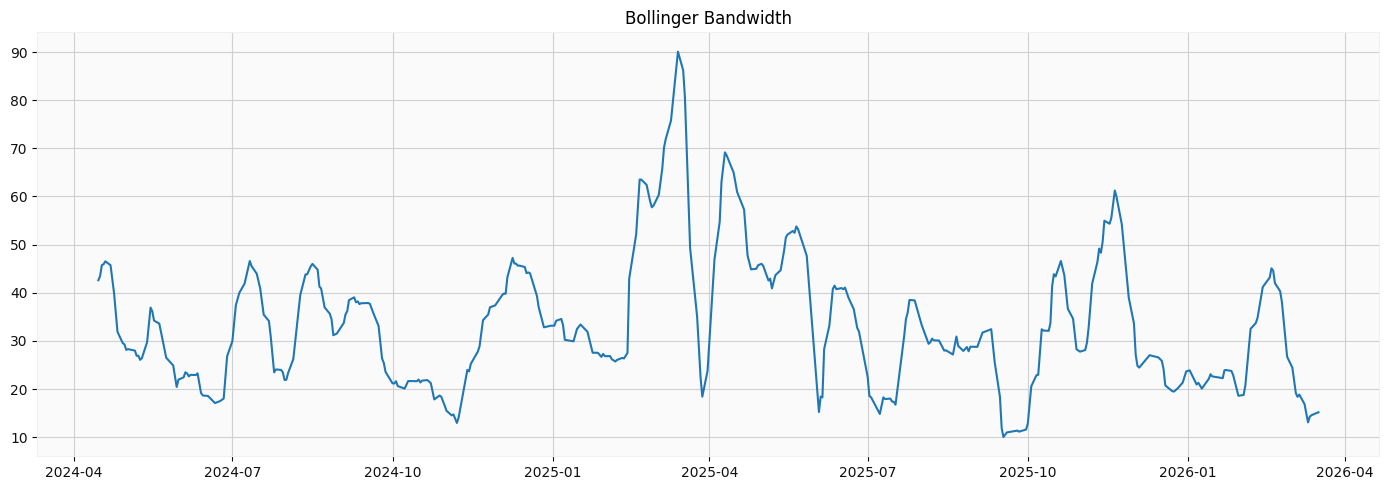

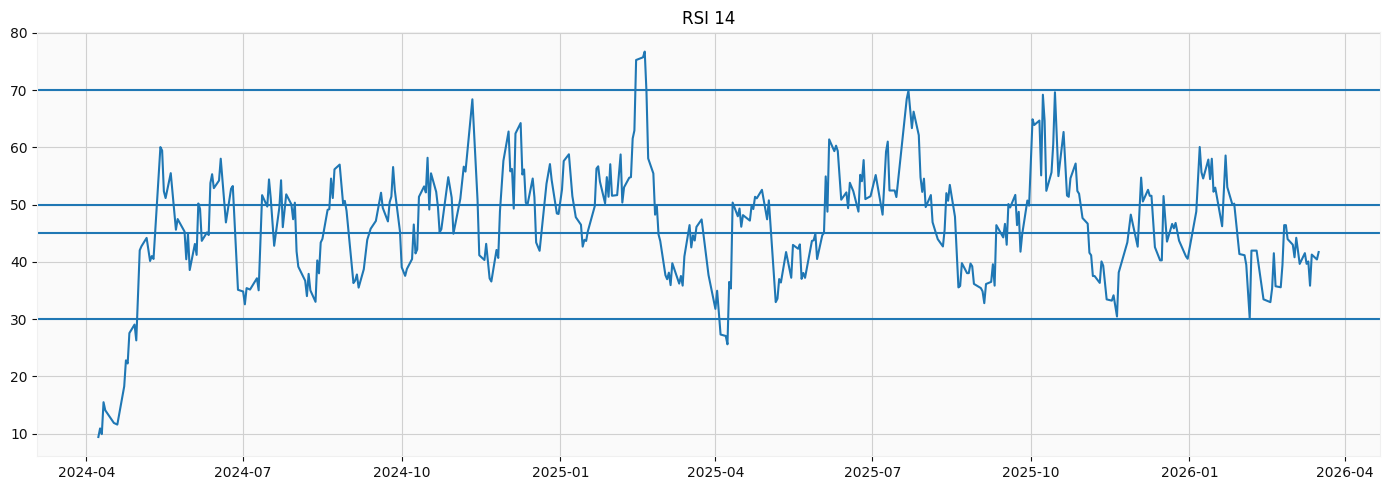

분석 완료
CSV 저장: RXRX_analysis_output.csv
엑셀 저장: RXRX_bollinger_analysis.xlsx
차트 저장: rxrx_price_bbands.png, rxrx_bandwidth.png, rxrx_rsi.png


In [2]:
# %%
# ==========================================
# RXRX Bollinger Analysis - Final Notebook Version
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import display, Markdown
from pathlib import Path

# ------------------------------------------
# 0) 사용자 설정
# ------------------------------------------
FILE_PATH = "RXRX_stock_with_indicators.csv"

OUTPUT_DIR = Path(".")
OUTPUT_CSV = OUTPUT_DIR / "RXRX_analysis_output.csv"
OUTPUT_XLSX = OUTPUT_DIR / "RXRX_bollinger_analysis.xlsx"

PRICE_BBANDS_PNG = OUTPUT_DIR / "rxrx_price_bbands.png"
BANDWIDTH_PNG = OUTPUT_DIR / "rxrx_bandwidth.png"
RSI_PNG = OUTPUT_DIR / "rxrx_rsi.png"

LOOKBACK_PERCENTILE = 120
RECENT_DAYS_FOR_LOG = 60
RECENT_DAYS_FOR_INTERPRET = 20
RECENT_EVENT_DAYS = 30

VOL_RATIO_BREAKOUT = 1.50
VOL_RATIO_FOLLOW = 1.10
RSI_BULL = 50
RSI_BEAR = 45
PRICE_MOVE_MIN_PCT = 2.0  # breakout / breakdown candle strength
SQUEEZE_THRESHOLD = 10    # percentile <= 10
TIGHT_THRESHOLD = 20      # percentile <= 20

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 220)
pd.set_option("display.max_colwidth", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# %%
# ------------------------------------------
# 1) 유틸 함수
# ------------------------------------------
def safe_fmt(x, digits=2):
    if pd.isna(x):
        return "N/A"
    return f"{x:.{digits}f}"

def safe_pct_change(start, end):
    if pd.isna(start) or pd.isna(end) or start == 0:
        return np.nan
    return (end - start) / start * 100

def bool_to_text(x):
    if pd.isna(x):
        return "N/A"
    return "Yes" if bool(x) else "No"

def section(title):
    display(Markdown(f"## {title}"))

def subsection(title):
    display(Markdown(f"### {title}"))

def classify_squeeze(percentile):
    if pd.isna(percentile):
        return np.nan
    if percentile <= 5:
        return "Ultra squeeze"
    elif percentile <= 10:
        return "Squeeze"
    elif percentile <= 20:
        return "Tight"
    else:
        return "Normal"

def classify_signal_strength(score_diff_abs):
    if pd.isna(score_diff_abs):
        return "Unknown"
    if score_diff_abs >= 5:
        return "Strong"
    elif score_diff_abs >= 3:
        return "Moderate"
    elif score_diff_abs >= 1:
        return "Weak"
    return "Flat"

def make_bullet_lines(lines):
    return "\n".join([f"- {line}" for line in lines if str(line).strip()])

# %%
# ------------------------------------------
# 2) 데이터 불러오기 및 검증
# ------------------------------------------
df = pd.read_csv(FILE_PATH)

required_cols = [
    "Date", "Close", "Volume",
    "BB_UPPER", "BB_MID", "BB_LOWER",
    "RSI_14"
]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"필수 컬럼이 없습니다: {missing}")

df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)

# MA_20이 없는 경우 BB_MID를 사용
if "MA_20" not in df.columns:
    df["MA_20"] = df["BB_MID"]

# 있으면 같이 활용
for ma_col in ["MA_5", "MA_20", "MA_60", "MA_120", "MA_240"]:
    if ma_col not in df.columns:
        df[ma_col] = np.nan

# %%
# ------------------------------------------
# 3) 핵심 지표 계산
# ------------------------------------------
df["BB_WIDTH"] = ((df["BB_UPPER"] - df["BB_LOWER"]) / df["BB_MID"]) * 100
df["VOL_MA20"] = df["Volume"].rolling(20).mean()
df["VOL_RATIO_20"] = df["Volume"] / df["VOL_MA20"]

df["PRICE_CHANGE_PCT"] = df["Close"].pct_change() * 100
df["BW_DELTA"] = df["BB_WIDTH"].diff()
df["BW_DELTA_PCT"] = df["BB_WIDTH"].pct_change() * 100

df["RET_3D_PCT"] = df["Close"].pct_change(3) * 100
df["RET_5D_PCT"] = df["Close"].pct_change(5) * 100

df["ABOVE_MA20"] = df["Close"] > df["MA_20"]
df["ABOVE_MA60"] = df["Close"] > df["MA_60"]

df["RSI_REGIME"] = np.select(
    [
        df["RSI_14"] >= 60,
        df["RSI_14"] >= 50,
        df["RSI_14"] <= 40,
        df["RSI_14"] <= 45,
    ],
    [
        "Bullish",
        "Bullish-neutral",
        "Bearish",
        "Bearish-neutral",
    ],
    default="Neutral"
)

# 최근 3일 연속 밴드폭 확대/축소
df["BW_EXPANSION_3D"] = (
    (df["BB_WIDTH"] > df["BB_WIDTH"].shift(1)) &
    (df["BB_WIDTH"].shift(1) > df["BB_WIDTH"].shift(2))
)

df["BW_CONTRACTION_3D"] = (
    (df["BB_WIDTH"] < df["BB_WIDTH"].shift(1)) &
    (df["BB_WIDTH"].shift(1) < df["BB_WIDTH"].shift(2))
)

# %%
# ------------------------------------------
# 4) 120일 밴드폭 percentile 계산
# ------------------------------------------
percentiles = []
for i in range(len(df)):
    if i < LOOKBACK_PERCENTILE:
        percentiles.append(np.nan)
    else:
        window = df["BB_WIDTH"].iloc[i - LOOKBACK_PERCENTILE:i]
        current = df["BB_WIDTH"].iloc[i]
        pct = (window <= current).mean() * 100
        percentiles.append(pct)

df["BW_PERCENTILE_120"] = percentiles
df["SQUEEZE_LEVEL"] = df["BW_PERCENTILE_120"].apply(classify_squeeze)
df["SQUEEZE"] = df["BW_PERCENTILE_120"] <= SQUEEZE_THRESHOLD
df["TIGHT"] = df["BW_PERCENTILE_120"] <= TIGHT_THRESHOLD

# %%
# ------------------------------------------
# 5) 밴드 돌파 / 이탈 / 후보 신호
# ------------------------------------------
df["UPPER_BREAK"] = df["Close"] > df["BB_UPPER"]
df["LOWER_BREAK"] = df["Close"] < df["BB_LOWER"]

# breakout / breakdown "캔들 강도" 필터
df["STRONG_UP_DAY"] = df["PRICE_CHANGE_PCT"] >= PRICE_MOVE_MIN_PCT
df["STRONG_DOWN_DAY"] = df["PRICE_CHANGE_PCT"] <= -PRICE_MOVE_MIN_PCT

# 후보 신호
df["BULLISH_CANDIDATE"] = (
    df["UPPER_BREAK"] &
    (df["VOL_RATIO_20"] >= VOL_RATIO_BREAKOUT) &
    (df["RSI_14"] >= RSI_BULL) &
    (df["BW_DELTA"] > 0) &
    (df["Close"] > df["MA_20"]) &
    (df["STRONG_UP_DAY"])
)

df["BEARISH_CANDIDATE"] = (
    df["LOWER_BREAK"] &
    (df["VOL_RATIO_20"] >= VOL_RATIO_BREAKOUT) &
    (df["RSI_14"] <= RSI_BEAR) &
    (df["BW_DELTA"] > 0) &
    (df["Close"] < df["MA_20"]) &
    (df["STRONG_DOWN_DAY"])
)

# %%
# ------------------------------------------
# 6) 스코어링
# ------------------------------------------
bull_scores = []
bear_scores = []

for _, row in df.iterrows():
    bull = 0
    bear = 0

    # 추세
    if pd.notna(row["MA_20"]):
        if row["Close"] > row["MA_20"]:
            bull += 1
        else:
            bear += 1

    if pd.notna(row["MA_60"]):
        if row["Close"] > row["MA_60"]:
            bull += 1
        else:
            bear += 1

    # RSI
    if row["RSI_14"] >= 60:
        bull += 2
    elif row["RSI_14"] >= 50:
        bull += 1
    elif row["RSI_14"] <= 40:
        bear += 2
    elif row["RSI_14"] <= 45:
        bear += 1

    # 거래량
    if row["VOL_RATIO_20"] >= 1.8:
        if row["Close"] >= row["MA_20"]:
            bull += 2
        else:
            bear += 2
    elif row["VOL_RATIO_20"] >= 1.2:
        if row["Close"] >= row["MA_20"]:
            bull += 1
        else:
            bear += 1

    # 밴드 돌파
    if row["UPPER_BREAK"]:
        bull += 3
    if row["LOWER_BREAK"]:
        bear += 3

    # 밴드폭 확장
    if row["BW_DELTA"] > 0:
        if row["Close"] >= row["MA_20"]:
            bull += 1
        else:
            bear += 1

    # 단기 수익률
    if pd.notna(row["RET_3D_PCT"]):
        if row["RET_3D_PCT"] >= 4:
            bull += 1
        elif row["RET_3D_PCT"] <= -4:
            bear += 1

    bull_scores.append(bull)
    bear_scores.append(bear)

df["BULL_SCORE"] = bull_scores
df["BEAR_SCORE"] = bear_scores
df["SCORE_DIFF"] = df["BULL_SCORE"] - df["BEAR_SCORE"]
df["SIGNAL_STRENGTH"] = df["SCORE_DIFF"].abs().apply(classify_signal_strength)

# %%
# ------------------------------------------
# 7) 기본 신호 판정
# ------------------------------------------
def compute_base_signal(row):
    # 확정 후보 우선
    if row["BULLISH_CANDIDATE"]:
        return "Bullish breakout candidate"
    if row["BEARISH_CANDIDATE"]:
        return "Bearish breakdown candidate"

    # squeeze / release
    if row["SQUEEZE"]:
        if row["BW_EXPANSION_3D"]:
            if row["SCORE_DIFF"] >= 2:
                return "Squeeze release watch (bullish bias)"
            elif row["SCORE_DIFF"] <= -2:
                return "Squeeze release watch (bearish bias)"
            else:
                return "Squeeze release watch"
        return "Squeeze watch"

    # tight but not squeeze
    if row["TIGHT"]:
        if row["SCORE_DIFF"] >= 2:
            return "Tight range with bullish bias"
        elif row["SCORE_DIFF"] <= -2:
            return "Tight range with bearish bias"
        else:
            return "Tight range"

    # expansion
    if row["BW_EXPANSION_3D"]:
        if row["SCORE_DIFF"] >= 3:
            return "Expansion with bullish bias"
        elif row["SCORE_DIFF"] <= -3:
            return "Expansion with bearish bias"
        return "Expansion without full confirmation"

    # 평상시
    if row["SCORE_DIFF"] >= 3:
        return "Bullish trend bias"
    elif row["SCORE_DIFF"] <= -3:
        return "Bearish trend bias"
    return "Neutral"

df["BASE_SIGNAL"] = df.apply(compute_base_signal, axis=1)

# %%
# ------------------------------------------
# 8) Follow-through 확인 로직
# ------------------------------------------
# 아이디어:
# 오늘 breakout candidate가 나왔으면
# 다음날에도 가격 유지 / 거래량 / RSI / 상단 밴드 인근 유지 여부를 체크하여
# confirmed / failed 로 재분류

df["FOLLOW_BULL"] = False
df["FOLLOW_BEAR"] = False
df["FAILED_BULL"] = False
df["FAILED_BEAR"] = False

for i in range(len(df) - 1):
    today = df.iloc[i]
    nxt = df.iloc[i + 1]

    # Bullish follow-through
    if today["BULLISH_CANDIDATE"]:
        bull_follow = (
            (nxt["Close"] >= today["Close"] * 0.985) and   # 다음날 급반락 회피
            (nxt["Close"] >= nxt["MA_20"]) and
            (nxt["RSI_14"] >= 50) and
            ((nxt["UPPER_BREAK"]) or (nxt["Close"] >= nxt["BB_MID"])) and
            (nxt["VOL_RATIO_20"] >= VOL_RATIO_FOLLOW or nxt["PRICE_CHANGE_PCT"] >= 0)
        )
        if bull_follow:
            df.loc[df.index[i + 1], "FOLLOW_BULL"] = True
        else:
            df.loc[df.index[i + 1], "FAILED_BULL"] = True

    # Bearish follow-through
    if today["BEARISH_CANDIDATE"]:
        bear_follow = (
            (nxt["Close"] <= today["Close"] * 1.015) and   # 다음날 급반등 회피
            (nxt["Close"] <= nxt["MA_20"]) and
            (nxt["RSI_14"] <= 45) and
            ((nxt["LOWER_BREAK"]) or (nxt["Close"] <= nxt["BB_MID"])) and
            (nxt["VOL_RATIO_20"] >= VOL_RATIO_FOLLOW or nxt["PRICE_CHANGE_PCT"] <= 0)
        )
        if bear_follow:
            df.loc[df.index[i + 1], "FOLLOW_BEAR"] = True
        else:
            df.loc[df.index[i + 1], "FAILED_BEAR"] = True

# 최종 신호 재정의
def compute_final_signal(row):
    if row["FOLLOW_BULL"]:
        return "Bullish breakout confirmed"
    if row["FOLLOW_BEAR"]:
        return "Bearish breakdown confirmed"
    if row["FAILED_BULL"]:
        return "Failed bullish breakout"
    if row["FAILED_BEAR"]:
        return "Failed bearish breakdown"
    return row["BASE_SIGNAL"]

df["SIGNAL"] = df["BASE_SIGNAL"].copy()
mask_follow = df["FOLLOW_BULL"] | df["FOLLOW_BEAR"] | df["FAILED_BULL"] | df["FAILED_BEAR"]
df.loc[mask_follow, "SIGNAL"] = df.loc[mask_follow].apply(compute_final_signal, axis=1)

# %%
# ------------------------------------------
# 9) 이벤트 로그 생성
# ------------------------------------------
event_rows = []

for i, row in df.iterrows():
    event_type = None
    details = []

    if row["BULLISH_CANDIDATE"]:
        event_type = "Bullish breakout candidate"
        details.append("상단 밴드 돌파")
        details.append("거래량 증가")
        details.append("RSI 강세")
        details.append("밴드폭 확대")
    elif row["BEARISH_CANDIDATE"]:
        event_type = "Bearish breakdown candidate"
        details.append("하단 밴드 이탈")
        details.append("거래량 증가")
        details.append("RSI 약세")
        details.append("밴드폭 확대")
    elif row["FOLLOW_BULL"]:
        event_type = "Bullish breakout confirmed"
        details.append("다음날 follow-through 확인")
    elif row["FOLLOW_BEAR"]:
        event_type = "Bearish breakdown confirmed"
        details.append("다음날 follow-through 확인")
    elif row["FAILED_BULL"]:
        event_type = "Failed bullish breakout"
        details.append("후속 상승 유지 실패")
    elif row["FAILED_BEAR"]:
        event_type = "Failed bearish breakdown"
        details.append("후속 하락 유지 실패")
    elif row["SQUEEZE"] and row["BW_EXPANSION_3D"]:
        event_type = "Squeeze release"
        details.append("squeeze 이후 밴드폭 확대")
    elif row["SQUEEZE"]:
        event_type = "Squeeze"
        details.append("변동성 압축")

    if event_type is not None:
        event_rows.append({
            "Date": row["Date"],
            "Event_Type": event_type,
            "Close": row["Close"],
            "BB_WIDTH": row["BB_WIDTH"],
            "BW_PERCENTILE_120": row["BW_PERCENTILE_120"],
            "RSI_14": row["RSI_14"],
            "VOL_RATIO_20": row["VOL_RATIO_20"],
            "Signal": row["SIGNAL"],
            "Details": ", ".join(details)
        })

events_df = pd.DataFrame(event_rows)

# %%
# ------------------------------------------
# 10) 최근 변화 분석
# ------------------------------------------
latest = df.dropna(subset=["BB_WIDTH"]).iloc[-1]

lookbacks = {
    "1W": 5,
    "2W": 10,
    "3W": 15,
    "4W": 20
}

changes = []
for label, n in lookbacks.items():
    if len(df) > n:
        past = df["BB_WIDTH"].iloc[-n - 1]
        now = latest["BB_WIDTH"]
        diff = now - past
        pct = diff / past * 100 if past != 0 else np.nan

        changes.append({
            "Period": label,
            "Past_BW": past,
            "Current_BW": now,
            "Change": diff,
            "Change_%": pct
        })

changes_df = pd.DataFrame(changes)

# %%
# ------------------------------------------
# 11) 해석 함수
# ------------------------------------------
def interpret_latest(row):
    lines = []

    lines.append(f"기준일은 {row['Date'].date()} 입니다.")
    lines.append(f"종가는 {safe_fmt(row['Close'])}, 볼린저 밴드폭은 {safe_fmt(row['BB_WIDTH'])}% 입니다.")
    lines.append(f"최근 120거래일 기준 밴드폭 percentile은 {safe_fmt(row['BW_PERCENTILE_120'])}% 이고, squeeze 수준은 '{row['SQUEEZE_LEVEL']}' 입니다.")
    lines.append(f"RSI(14)는 {safe_fmt(row['RSI_14'])}, 거래량 비율은 {safe_fmt(row['VOL_RATIO_20'])}배 입니다.")
    lines.append(f"bull score는 {safe_fmt(row['BULL_SCORE'], 0)}, bear score는 {safe_fmt(row['BEAR_SCORE'], 0)}, score diff는 {safe_fmt(row['SCORE_DIFF'], 0)} 입니다.")
    lines.append(f"현재 최종 신호는 '{row['SIGNAL']}' 이며 강도는 '{row['SIGNAL_STRENGTH']}' 입니다.")

    # 상태 해석
    signal = str(row["SIGNAL"])

    if signal == "Bullish breakout confirmed":
        lines.append("상단 밴드 돌파 이후 다음날 follow-through가 확인되어, 단순 일시적 급등보다 지속성 있는 상승 돌파로 해석할 수 있습니다.")
    elif signal == "Bearish breakdown confirmed":
        lines.append("하단 밴드 이탈 이후 다음날 follow-through가 확인되어, 단순 흔들림보다 지속성 있는 하락 이탈로 해석할 수 있습니다.")
    elif signal == "Bullish breakout candidate":
        lines.append("상승 돌파 후보가 발생했지만, 아직 다음날 follow-through가 확인되지 않았으므로 확정 신호보다는 후보 신호로 보는 것이 적절합니다.")
    elif signal == "Bearish breakdown candidate":
        lines.append("하락 이탈 후보가 발생했지만, 아직 다음날 follow-through가 확인되지 않았으므로 확정 신호보다는 후보 신호로 보는 것이 적절합니다.")
    elif signal == "Failed bullish breakout":
        lines.append("직전 상방 돌파 시도가 있었으나 다음날 유지에 실패하여 가짜 돌파일 가능성이 높아졌습니다.")
    elif signal == "Failed bearish breakdown":
        lines.append("직전 하방 이탈 시도가 있었으나 다음날 유지에 실패하여 가짜 하락 이탈 가능성이 높아졌습니다.")
    elif "Squeeze" in signal:
        lines.append("현재는 변동성 압축 구간 또는 압축 해제 직전 구간으로, 방향성이 정해지기 전 에너지가 축적되는 단계로 해석됩니다.")
    elif "Expansion" in signal:
        lines.append("밴드폭이 확대되고 있어 변동성이 살아나는 중이며, 아직 확정 돌파는 아니지만 추세 전개 초기일 가능성을 살펴볼 필요가 있습니다.")
    elif "Bullish trend bias" in signal:
        lines.append("추세 및 모멘텀 점수상 상방 우위가 관찰되지만, 명확한 밴드 돌파 확정은 부족한 상태입니다.")
    elif "Bearish trend bias" in signal:
        lines.append("추세 및 모멘텀 점수상 하방 우위가 관찰되지만, 명확한 밴드 이탈 확정은 부족한 상태입니다.")
    else:
        lines.append("현재는 뚜렷한 방향성 확정 신호가 부족한 중립 상태로 해석됩니다.")

    watch = []
    if row["Close"] <= row["BB_UPPER"]:
        watch.append("상단 밴드 종가 돌파 여부")
    if row["Close"] >= row["BB_LOWER"]:
        watch.append("하단 밴드 종가 이탈 여부")
    if row["VOL_RATIO_20"] < VOL_RATIO_BREAKOUT:
        watch.append("거래량 증가 동반 여부")
    if row["RSI_14"] < 50 and row["SCORE_DIFF"] >= 0:
        watch.append("RSI 50 회복 여부")
    if row["RSI_14"] > 45 and row["SCORE_DIFF"] < 0:
        watch.append("RSI 45 하향 여부")
    if row["BW_DELTA"] <= 0:
        watch.append("밴드폭 재확대 여부")
    if row["SIGNAL"] in ["Bullish breakout candidate", "Bearish breakdown candidate"]:
        watch.append("다음날 follow-through 확인")

    if watch:
        lines.append("추가 확인 포인트는 " + ", ".join(watch) + " 입니다.")

    return "\n".join(lines)

def interpret_recent_period(data, n=20):
    recent = data.dropna(subset=["BB_WIDTH"]).tail(n).copy()
    if len(recent) < 5:
        return "최근 구간 해석을 하기에는 데이터가 부족합니다."

    start = recent.iloc[0]
    end = recent.iloc[-1]

    price_start = start["Close"]
    price_end = end["Close"]
    price_change_pct = safe_pct_change(price_start, price_end)

    bw_start = start["BB_WIDTH"]
    bw_end = end["BB_WIDTH"]
    bw_change_pct = safe_pct_change(bw_start, bw_end)

    avg_vol_ratio = recent["VOL_RATIO_20"].mean()
    avg_rsi = recent["RSI_14"].mean()
    squeeze_days = int(recent["SQUEEZE"].fillna(False).sum())
    tight_days = int(recent["TIGHT"].fillna(False).sum())
    upper_breaks = int(recent["UPPER_BREAK"].fillna(False).sum())
    lower_breaks = int(recent["LOWER_BREAK"].fillna(False).sum())

    dominant_signal = recent["SIGNAL"].mode().iloc[0] if not recent["SIGNAL"].mode().empty else "N/A"
    max_close = recent["Close"].max()
    min_close = recent["Close"].min()
    range_pct = safe_pct_change(min_close, max_close)

    lines = []
    lines.append(f"최근 {len(recent)}거래일 구간은 {start['Date'].date()} 부터 {end['Date'].date()} 까지입니다.")
    lines.append(f"종가는 {safe_fmt(price_start)} 에서 {safe_fmt(price_end)} 로 변했고, 누적 변화율은 {safe_fmt(price_change_pct)}% 입니다.")
    lines.append(f"같은 기간 볼린저 밴드폭은 {safe_fmt(bw_start)}% 에서 {safe_fmt(bw_end)}% 로 변했고, 변화율은 {safe_fmt(bw_change_pct)}% 입니다.")
    lines.append(f"구간 내 가격 범위는 {safe_fmt(min_close)} ~ {safe_fmt(max_close)} 이며, 고저 범위는 약 {safe_fmt(range_pct)}% 입니다.")
    lines.append(f"평균 거래량 비율은 {safe_fmt(avg_vol_ratio)}배, 평균 RSI는 {safe_fmt(avg_rsi)} 입니다.")
    lines.append(f"squeeze 일수는 {squeeze_days}일, tight 구간 일수는 {tight_days}일, 상단 돌파는 {upper_breaks}회, 하단 이탈은 {lower_breaks}회 입니다.")
    lines.append(f"가장 자주 등장한 최종 신호는 '{dominant_signal}' 입니다.")

    if pd.notna(bw_change_pct):
        if bw_change_pct <= -20:
            lines.append("최근 구간에서 밴드폭이 뚜렷하게 축소되어 변동성 압축이 진행된 것으로 해석됩니다.")
        elif bw_change_pct >= 20:
            lines.append("최근 구간에서 밴드폭이 확대되어 변동성이 살아나는 과정으로 해석됩니다.")
        else:
            lines.append("최근 구간의 밴드폭 변화는 제한적이며, 변동성 방향성은 아직 강하게 확정되지 않았습니다.")

    if squeeze_days >= max(3, int(n * 0.3)):
        lines.append("구간의 상당 부분이 squeeze 상태였으므로 에너지 축적 또는 박스권 압축 구간일 가능성이 높습니다.")

    if avg_vol_ratio < 1.0:
        lines.append("평균 거래량이 평시보다 낮아 강한 추종 자금 유입은 아직 제한적인 상태입니다.")
    elif avg_vol_ratio >= 1.2:
        lines.append("평균 거래량이 평시 대비 높은 편이어서 움직임의 신뢰도를 높일 수 있습니다.")
    else:
        lines.append("거래량은 대체로 평균 부근이며, 거래량만으로 강한 방향성을 확정하기는 어렵습니다.")

    if avg_rsi >= 55:
        lines.append("평균 RSI가 강세권에 가까워 상방 우위가 상대적으로 더 강합니다.")
    elif avg_rsi <= 45:
        lines.append("평균 RSI가 약세권에 가까워 하방 압력이 아직 남아 있다고 볼 수 있습니다.")
    else:
        lines.append("평균 RSI는 중립권에 가까워 방향성 확정은 아직 부족합니다.")

    return "\n".join(lines)

def interpret_events(events_df, n=30):
    if events_df.empty:
        return "최근 이벤트가 없습니다."

    recent_events = events_df.tail(n).copy()
    counts = recent_events["Event_Type"].value_counts().to_dict()

    lines = []
    lines.append(f"최근 이벤트 로그 기준으로 마지막 {len(recent_events)}개 이벤트를 검토했습니다.")
    for event_type, cnt in counts.items():
        lines.append(f"'{event_type}' 는 {cnt}회 발생했습니다.")

    if "Bullish breakout confirmed" in counts:
        lines.append("확정된 상승 돌파 이벤트가 존재하므로, 단순 감시 단계를 넘어 실제 추세 전개가 있었는지 추가 확인이 필요합니다.")
    if "Bearish breakdown confirmed" in counts:
        lines.append("확정된 하락 이탈 이벤트가 존재하므로, 약세 추세 전개 가능성을 더 신중히 볼 필요가 있습니다.")
    if "Failed bullish breakout" in counts or "Failed bearish breakdown" in counts:
        lines.append("실패한 돌파 이벤트가 있었다면 최근 구간에 허위 신호가 존재했음을 의미하므로, 후속 거래량과 유지력을 더 중시해야 합니다.")
    if "Squeeze" in counts or "Squeeze release" in counts:
        lines.append("squeeze 또는 release 이벤트가 반복되면, 큰 방향성 움직임 직전의 압축-해제 패턴일 가능성을 고려할 수 있습니다.")

    return "\n".join(lines)

def make_action_guide(row):
    lines = []
    lines.append("상방 확인 기준: 종가가 BB_UPPER 위에서 마감하고, 거래량 비율이 1.5 이상이며, RSI가 50 이상 유지되는지 확인합니다.")
    lines.append("하방 확인 기준: 종가가 BB_LOWER 아래에서 마감하고, 거래량 비율이 1.5 이상이며, RSI가 45 이하로 약화되는지 확인합니다.")
    lines.append("진짜 돌파 여부는 당일 신호보다 다음날 follow-through 유지 여부를 더 중요하게 봅니다.")
    lines.append("밴드폭이 다시 커지면서 가격이 밴드 바깥 또는 중심선 위아래에서 안착하는지 확인하는 것이 중요합니다.")

    sig = str(row["SIGNAL"])
    if sig == "Squeeze watch":
        lines.append("현재는 스퀴즈 감시 단계이므로, 성급한 방향 추정보다 돌파와 거래량 동반 여부를 기다리는 접근이 적절합니다.")
    elif "candidate" in sig.lower():
        lines.append("현재는 후보 신호 단계이므로, 다음 거래일의 유지력 확인 전까지는 확정 신호처럼 과대해석하지 않는 것이 좋습니다.")
    elif "confirmed" in sig.lower():
        lines.append("현재는 확인된 신호 단계이므로, 추세 지속성과 거래량 유지 여부를 중심으로 관리하는 것이 좋습니다.")
    elif "failed" in sig.lower():
        lines.append("직전 돌파 시도가 실패한 상태이므로, 반대 방향 재전개 가능성까지 열어 두고 보수적으로 해석하는 편이 좋습니다.")
    else:
        lines.append("현재는 중립 또는 편향 단계이므로, 단독 지표보다 가격, 거래량, 밴드폭의 동시 확인이 중요합니다.")

    return "\n".join(lines)

def make_risk_checklist(row):
    risks = []

    if row["VOL_RATIO_20"] < 1.0:
        risks.append("거래량이 평균 이하라 신호 신뢰도가 낮을 수 있습니다.")
    if row["BW_DELTA"] <= 0:
        risks.append("밴드폭이 재확대되지 않으면 방향성 신호가 약할 수 있습니다.")
    if 45 <= row["RSI_14"] <= 55:
        risks.append("RSI가 중립권이라 방향성이 애매할 수 있습니다.")
    if row["SIGNAL"] in ["Bullish breakout candidate", "Bearish breakdown candidate"]:
        risks.append("다음날 follow-through 미확인 상태라 가짜 돌파일 수 있습니다.")
    if row["SIGNAL"] in ["Failed bullish breakout", "Failed bearish breakdown"]:
        risks.append("최근 실패 신호가 발생해 변동성 함정 구간일 수 있습니다.")
    if row["SQUEEZE"] and not row["BW_EXPANSION_3D"]:
        risks.append("스퀴즈는 확인되지만 아직 release가 시작되지 않았습니다.")

    if not risks:
        risks.append("현재 특별히 두드러진 리스크는 제한적이지만, 단일 지표 의존은 피하는 것이 좋습니다.")

    return "\n".join(risks)

# %%
# ------------------------------------------
# 12) 요약 테이블 및 텍스트 리포트
# ------------------------------------------
summary = pd.DataFrame({
    "Metric": [
        "Latest Date",
        "Close",
        "BB Width",
        "BW Percentile(120d)",
        "Squeeze Level",
        "RSI_14",
        "Volume Ratio(20)",
        "BULL_SCORE",
        "BEAR_SCORE",
        "SCORE_DIFF",
        "Signal Strength",
        "UPPER_BREAK",
        "LOWER_BREAK",
        "Current Signal"
    ],
    "Value": [
        latest["Date"],
        latest["Close"],
        latest["BB_WIDTH"],
        latest["BW_PERCENTILE_120"],
        latest["SQUEEZE_LEVEL"],
        latest["RSI_14"],
        latest["VOL_RATIO_20"],
        latest["BULL_SCORE"],
        latest["BEAR_SCORE"],
        latest["SCORE_DIFF"],
        latest["SIGNAL_STRENGTH"],
        latest["UPPER_BREAK"],
        latest["LOWER_BREAK"],
        latest["SIGNAL"]
    ]
})

latest_interpretation = interpret_latest(latest)
recent_20d_interpretation = interpret_recent_period(df, n=RECENT_DAYS_FOR_INTERPRET)
events_interpretation = interpret_events(events_df, n=RECENT_EVENT_DAYS)
action_guide = make_action_guide(latest)
risk_checklist = make_risk_checklist(latest)

text_report = pd.DataFrame({
    "Section": [
        "Latest Interpretation",
        "Recent 20D Interpretation",
        "Recent Events Interpretation",
        "Action Guide",
        "Risk Checklist"
    ],
    "Text": [
        latest_interpretation,
        recent_20d_interpretation,
        events_interpretation,
        action_guide,
        risk_checklist
    ]
})

# %%
# ------------------------------------------
# 13) 노트북 셀 출력
# ------------------------------------------
section("Summary")
display(summary)

section("Recent Changes")
display(changes_df)

section(f"Recent {RECENT_DAYS_FOR_INTERPRET} Days Snapshot")
recent_view_cols = [
    "Date", "Close", "PRICE_CHANGE_PCT", "BB_WIDTH", "BW_DELTA",
    "BW_PERCENTILE_120", "SQUEEZE_LEVEL", "RSI_14", "VOL_RATIO_20",
    "BULL_SCORE", "BEAR_SCORE", "SCORE_DIFF",
    "UPPER_BREAK", "LOWER_BREAK", "BULLISH_CANDIDATE", "BEARISH_CANDIDATE",
    "FOLLOW_BULL", "FOLLOW_BEAR", "FAILED_BULL", "FAILED_BEAR",
    "SIGNAL"
]
display(df.tail(RECENT_DAYS_FOR_INTERPRET)[recent_view_cols])

section(f"Recent Events (last {RECENT_EVENT_DAYS} rows)")
if not events_df.empty:
    display(events_df.tail(RECENT_EVENT_DAYS))
else:
    print("최근 이벤트가 없습니다.")

section("Latest Interpretation")
print(latest_interpretation)

section("Recent 20D Interpretation")
print(recent_20d_interpretation)

section("Recent Events Interpretation")
print(events_interpretation)

section("Action Guide")
print(action_guide)

section("Risk Checklist")
print(risk_checklist)

# %%
# ------------------------------------------
# 14) 시각화
# ------------------------------------------
# 14-1 가격 + 볼린저 밴드
plt.figure(figsize=(14, 6))
plt.plot(df["Date"], df["Close"], label="Close")
plt.plot(df["Date"], df["BB_UPPER"], label="BB Upper")
plt.plot(df["Date"], df["BB_MID"], label="BB Mid")
plt.plot(df["Date"], df["BB_LOWER"], label="BB Lower")

# 최근 confirmed / failed 이벤트 마커
bull_conf = df[df["FOLLOW_BULL"]]
bear_conf = df[df["FOLLOW_BEAR"]]
bull_fail = df[df["FAILED_BULL"]]
bear_fail = df[df["FAILED_BEAR"]]

if not bull_conf.empty:
    plt.scatter(bull_conf["Date"], bull_conf["Close"], marker="^", label="Bull Confirm")
if not bear_conf.empty:
    plt.scatter(bear_conf["Date"], bear_conf["Close"], marker="v", label="Bear Confirm")
if not bull_fail.empty:
    plt.scatter(bull_fail["Date"], bull_fail["Close"], marker="x", label="Bull Fail")
if not bear_fail.empty:
    plt.scatter(bear_fail["Date"], bear_fail["Close"], marker="x", label="Bear Fail")

plt.title("RXRX Price and Bollinger Bands")
plt.legend()
plt.tight_layout()
plt.savefig(PRICE_BBANDS_PNG, dpi=150)
plt.show()
plt.close()

# 14-2 밴드폭
plt.figure(figsize=(14, 5))
plt.plot(df["Date"], df["BB_WIDTH"], label="BB Width")
plt.title("Bollinger Bandwidth")
plt.tight_layout()
plt.savefig(BANDWIDTH_PNG, dpi=150)
plt.show()
plt.close()

# 14-3 RSI
plt.figure(figsize=(14, 5))
plt.plot(df["Date"], df["RSI_14"], label="RSI(14)")
plt.axhline(70)
plt.axhline(50)
plt.axhline(45)
plt.axhline(30)
plt.title("RSI 14")
plt.tight_layout()
plt.savefig(RSI_PNG, dpi=150)
plt.show()
plt.close()

# %%
# ------------------------------------------
# 15) 결과 저장
# ------------------------------------------
df.to_csv(OUTPUT_CSV, index=False)

with pd.ExcelWriter(OUTPUT_XLSX, engine="openpyxl") as writer:
    summary.to_excel(writer, sheet_name="Summary", index=False)
    changes_df.to_excel(writer, sheet_name="Recent_Changes", index=False)
    df.tail(RECENT_DAYS_FOR_LOG).to_excel(writer, sheet_name="Signal_Log", index=False)
    events_df.to_excel(writer, sheet_name="Events", index=False)
    text_report.to_excel(writer, sheet_name="Interpretation", index=False)
    df.to_excel(writer, sheet_name="Analyzed_Data", index=False)

print("분석 완료")
print(f"CSV 저장: {OUTPUT_CSV}")
print(f"엑셀 저장: {OUTPUT_XLSX}")
print(f"차트 저장: {PRICE_BBANDS_PNG}, {BANDWIDTH_PNG}, {RSI_PNG}")